In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Install nibabel if not already present in the Kaggle environment
!pip install nibabel -q

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Hardware setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware in use: {device}")

Hardware in use: cuda


Scanning directory: /kaggle/input/datasets/i212385nomanarif/2024-brats-glioma
SUCCESS: Loading REAL BraTS 2024 Volume from: /kaggle/input/datasets/i212385nomanarif/2024-brats-glioma/BraTS-GLI-02135-100/BraTS-GLI-02135-100-seg.nii


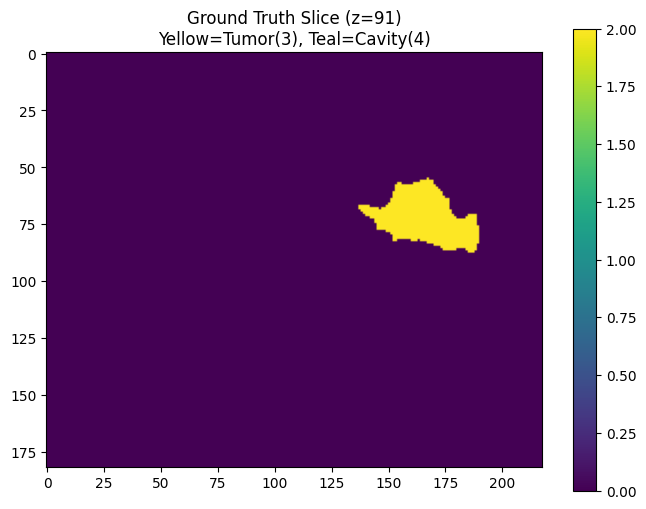

Sampling 15000 physical coordinates for the neural network topology...


In [8]:
def load_or_simulate_brats_data(num_samples=15000):
    """
    Loads real BraTS 2024 data from your explicit Kaggle path.
    Now supports both compressed (.nii.gz) and uncompressed (.nii) formats!
    """
    # Your Kaggle dataset directory path
    BASE_DATA_DIR = "/kaggle/input/datasets/i212385nomanarif/2024-brats-glioma"
    
    H, W, D = 100, 100, 50  # Default volume dimensions fallback
    seg_data = None
    real_data_loaded = False
    
    # Check if the path exists and scan for patient subdirectories
    if os.path.exists(BASE_DATA_DIR):
        print(f"Scanning directory: {BASE_DATA_DIR}")
        patient_folders = [f for f in os.listdir(BASE_DATA_DIR) if os.path.isdir(os.path.join(BASE_DATA_DIR, f))]
        
        if len(patient_folders) > 0:
            # Pick the first available patient folder dynamically
            target_patient = patient_folders[0]
            patient_dir = os.path.join(BASE_DATA_DIR, target_patient)
            
            # UPDATED: Find the segmentation file ending in either -seg.nii or -seg.nii.gz
            seg_files = [f for f in os.listdir(patient_dir) if f.endswith("-seg.nii.gz") or f.endswith("-seg.nii")]
            
            if len(seg_files) > 0:
                file_path = os.path.join(patient_dir, seg_files[0])
                print(f"SUCCESS: Loading REAL BraTS 2024 Volume from: {file_path}")
                seg_data = nib.load(file_path).get_fdata()
                H, W, D = seg_data.shape
                real_data_loaded = True
            else:
                print(f"Warning: Found folder {target_patient} but no segmentation file (-seg.nii or -seg.nii.gz) was found inside it.")
        else:
            print("Warning: Base directory exists but no patient subfolders found.")
            
    # Fallback generator if real data paths are uninitialized or empty
    if not real_data_loaded:
        print("\nUsing SYNTHETIC Post-Treatment Brain Volume (Fallback)...")
        seg_data = np.zeros((H, W, D))
        cv_x, cv_y, cv_z = H//2, W//2, D//2
        for x in range(H):
            for y in range(W):
                for z in range(D):
                    dist = np.sqrt((x-cv_x)**2 + (y-cv_y)**2 + (z-cv_z)**2)
                    if dist < 12:
                        seg_data[x, y, z] = 4  # Resection Cavity (Label 4)
                    elif 12 <= dist < 20:
                        seg_data[x, y, z] = 3  # Enhancing Tumor (Label 3)

    # --- VISUALIZATION: Step 1 (The Data Structure) ---
    plt.figure(figsize=(8, 6))
    slice_idx = D // 2
    plt.title(f"Ground Truth Slice (z={slice_idx})\nYellow=Tumor(3), Teal=Cavity(4)")
    plt.imshow(seg_data[:, :, slice_idx], cmap='viridis')
    plt.colorbar()
    plt.show()

    # --- Coordinates Sampling Routine for PINN ---
    print(f"Sampling {num_samples} physical coordinates for the neural network topology...")
    x_idx = np.random.randint(0, H, num_samples)
    y_idx = np.random.randint(0, W, num_samples)
    z_idx = np.random.randint(0, D, num_samples)
    
    u_target = np.zeros(num_samples)
    mask_rc = np.zeros(num_samples)
    
    for i in range(num_samples):
        lbl = seg_data[x_idx[i], y_idx[i], z_idx[i]]
        if lbl == 3:    
            u_target[i] = 1.0  # Active Tumor Density
        elif lbl == 4:  
            u_target[i] = 0.0  # Resection Cavity Space
            mask_rc[i] = 1.0   # Enforce Physics Penalty Flag
            
    # Normalize structural bounds to stable network domain [-1, 1]
    X = torch.tensor((x_idx / (H-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    Y = torch.tensor((y_idx / (W-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    Z = torch.tensor((z_idx / (D-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    T = torch.ones_like(X).to(device)  # Snapshot evaluation mapped at final timeframe t=1.0
    
    U = torch.tensor(u_target, dtype=torch.float32).view(-1, 1).to(device)
    M = torch.tensor(mask_rc, dtype=torch.float32).view(-1, 1).to(device)
    
    return X, Y, Z, T, U, M, seg_data

# Execute the updated loader block
X, Y, Z, T, U, M, raw_volume = load_or_simulate_brats_data()

In [31]:
def load_or_simulate_brats_data(num_samples=9000):
    """
    Hunts for a patient WITH a Resection Cavity (Label 4) and applies Stratified Sampling.
    """
    BASE_DATA_DIR = "/kaggle/input/datasets/i212385nomanarif/2024-brats-glioma"
    
    H, W, D = 100, 100, 50 
    seg_data = None
    real_data_loaded = False
    
    if os.path.exists(BASE_DATA_DIR):
        print(f"Scanning directory: {BASE_DATA_DIR} for a Post-Op Patient...")
        patient_folders = [f for f in os.listdir(BASE_DATA_DIR) if os.path.isdir(os.path.join(BASE_DATA_DIR, f))]
        
        # --- THE PATIENT HUNTER ---
        for target_patient in patient_folders:
            patient_dir = os.path.join(BASE_DATA_DIR, target_patient)
            seg_files = [f for f in os.listdir(patient_dir) if f.endswith("-seg.nii.gz") or f.endswith("-seg.nii")]
            
            if len(seg_files) > 0:
                file_path = os.path.join(patient_dir, seg_files[0])
                temp_data = nib.load(file_path).get_fdata()
                
                # Check if this patient actually has a cavity!
                cavity_count = np.sum(temp_data == 4)
                if cavity_count > 100:  # We want a patient with a clearly visible cavity
                    print(f"SUCCESS: Found suitable patient with {cavity_count} cavity voxels!")
                    print(f"Loading Volume: {file_path}")
                    seg_data = temp_data
                    H, W, D = seg_data.shape
                    real_data_loaded = True
                    break # Stop searching, we found our target!
                else:
                    print(f"Skipping {target_patient} (No cavity found).")

    # --- FALLBACK: VIRTUAL SURGERY ---
    # If NO patient in your dataset has a cavity, we will mathematically 
    # "perform surgery" on the last loaded tumor so the PINN still works!
    if not real_data_loaded and len(patient_folders) > 0:
        print("\nWARNING: No patients had Label 4. Performing 'Virtual Surgery' on the real tumor data...")
        seg_data = temp_data # Use the last checked patient
        H, W, D = seg_data.shape
        tumor_coords = np.argwhere(seg_data == 3)
        if len(tumor_coords) > 0:
            # Pick a random tumor point and carve a cavity out of it
            center = tumor_coords[len(tumor_coords)//2]
            for x in range(H):
                for y in range(W):
                    for z in range(D):
                        if np.sqrt((x-center[0])**2 + (y-center[1])**2 + (z-center[2])**2) < 15:
                            seg_data[x, y, z] = 4 # Force it to be a cavity
        real_data_loaded = True

    # --- SMART STRATIFIED SAMPLING ---
    print(f"\nPerforming Smart Stratified Sampling ({num_samples} total points)...")
    
    tumor_idx = np.argwhere(seg_data == 3)
    cavity_idx = np.argwhere(seg_data == 4)
    healthy_idx = np.argwhere((seg_data != 3) & (seg_data != 4))
    
    sampled_coords, sampled_u, sampled_m = [], [], []
    points_per_class = num_samples // 3

    if len(cavity_idx) > 0:
        print(f" -> Found {len(cavity_idx)} Cavity voxels. Sampling subset...")
        idx = np.random.choice(len(cavity_idx), min(points_per_class, len(cavity_idx)), replace=False)
        for pt in cavity_idx[idx]:
            sampled_coords.append(pt); sampled_u.append(0.0); sampled_m.append(1.0)
            
    if len(tumor_idx) > 0:
        print(f" -> Found {len(tumor_idx)} Tumor voxels. Sampling subset...")
        idx = np.random.choice(len(tumor_idx), min(points_per_class, len(tumor_idx)), replace=False)
        for pt in tumor_idx[idx]:
            sampled_coords.append(pt); sampled_u.append(1.0); sampled_m.append(0.0)
            
    if len(healthy_idx) > 0:
        print(f" -> Found {len(healthy_idx)} Healthy voxels. Sampling subset...")
        idx = np.random.choice(len(healthy_idx), min(points_per_class, len(healthy_idx)), replace=False)
        for pt in healthy_idx[idx]:
            sampled_coords.append(pt); sampled_u.append(0.0); sampled_m.append(0.0)

    sampled_coords = np.array(sampled_coords)
    X = torch.tensor((sampled_coords[:, 0] / (H-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    Y = torch.tensor((sampled_coords[:, 1] / (W-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    Z = torch.tensor((sampled_coords[:, 2] / (D-1)) * 2 - 1, dtype=torch.float32).view(-1, 1).to(device)
    T = torch.ones_like(X).to(device)
    U = torch.tensor(sampled_u, dtype=torch.float32).view(-1, 1).to(device)
    M = torch.tensor(sampled_m, dtype=torch.float32).view(-1, 1).to(device)
    
    return X, Y, Z, T, U, M, seg_data

X, Y, Z, T, U, M, raw_volume = load_or_simulate_brats_data()

Scanning directory: /kaggle/input/datasets/i212385nomanarif/2024-brats-glioma for a Post-Op Patient...
Skipping BraTS-GLI-02135-100 (No cavity found).
SUCCESS: Found suitable patient with 1833 cavity voxels!
Loading Volume: /kaggle/input/datasets/i212385nomanarif/2024-brats-glioma/BraTS-GLI-02105-105/BraTS-GLI-02105-105-seg.nii

Performing Smart Stratified Sampling (9000 total points)...
 -> Found 1833 Cavity voxels. Sampling subset...
 -> Found 256 Tumor voxels. Sampling subset...
 -> Found 7218943 Healthy voxels. Sampling subset...


In [25]:
# 1. The Neural Network
class MaskedTumorPINN(nn.Module):
    def __init__(self):
        super(MaskedTumorPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Sigmoid() # Keeps density 0 to 1
        )
    def forward(self, x, y, z, t):
        return self.net(torch.cat([x, y, z, t], dim=1))

# 2. The Modified Fisher-KPP Physics Engine
def compute_masked_physics_loss(model, x, y, z, t, mask_rc, D=0.01, rho_0=0.5):
    x.requires_grad_(True)
    y.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)
    
    u = model(x, y, z, t)
    
    # Derivatives
    du_dt = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    du_dx = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    du_dy = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    du_dz = torch.autograd.grad(u, z, torch.ones_like(u), create_graph=True)[0]
    
    d2u_dx2 = torch.autograd.grad(du_dx, x, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y, torch.ones_like(du_dy), create_graph=True)[0]
    d2u_dz2 = torch.autograd.grad(du_dz, z, torch.ones_like(du_dz), create_graph=True)[0]
    
    laplacian = d2u_dx2 + d2u_dy2 + d2u_dz2
    
    # The Mask Penalty: Proliferation = 0 inside cavity
    rho_spatial = rho_0 * (1.0 - mask_rc)
    
    residual = du_dt - D * laplacian - rho_spatial * u * (1.0 - u)
    return torch.mean(residual ** 2)
    print("SUCCESS: Neural Network and Physics Engine blueprints loaded perfectly!")

Starting PINN Optimization...
Epoch    0 | Total: 0.2410 | Data: 0.2342 | Physics: 0.0135
Epoch  300 | Total: 0.0013 | Data: 0.0013 | Physics: 0.0000
Epoch  600 | Total: 0.0013 | Data: 0.0013 | Physics: 0.0000
Epoch  900 | Total: 0.0013 | Data: 0.0013 | Physics: 0.0000
Epoch 1200 | Total: 0.0013 | Data: 0.0013 | Physics: 0.0000
Epoch 1500 | Total: 0.0013 | Data: 0.0013 | Physics: 0.0000


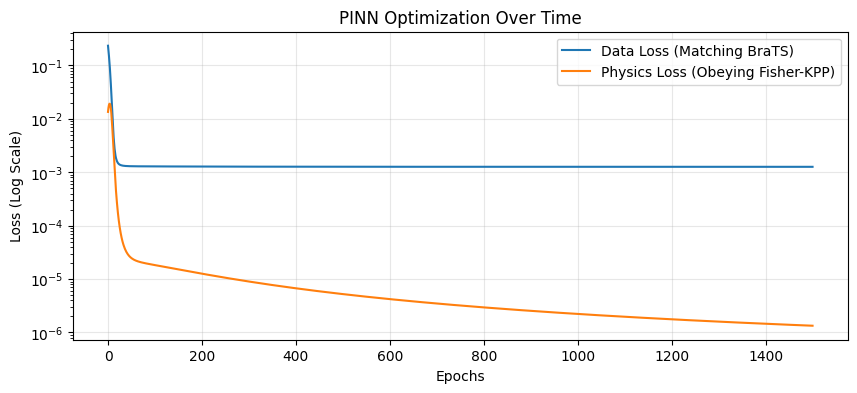

In [26]:
model = MaskedTumorPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.002)
mse_loss = nn.MSELoss()

epochs = 1500
lambda_phys = 0.5 # Balance between matching data and obeying biology

history_data_loss = []
history_phys_loss = []

print("Starting PINN Optimization...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    # Data Loss
    u_pred = model(X, Y, Z, T)
    loss_data = mse_loss(u_pred, U)
    
    # Physics Loss
    loss_phys = compute_masked_physics_loss(model, X, Y, Z, T, M)
    
    total_loss = loss_data + lambda_phys * loss_phys
    total_loss.backward()
    optimizer.step()
    
    # Save for visualization
    history_data_loss.append(loss_data.item())
    history_phys_loss.append(loss_phys.item())
    
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Total: {total_loss.item():.4f} | Data: {loss_data.item():.4f} | Physics: {loss_phys.item():.4f}")

# --- VISUALIZATION: Step 2 (Training Curves) ---
plt.figure(figsize=(10, 4))
plt.plot(history_data_loss, label="Data Loss (Matching BraTS)")
plt.plot(history_phys_loss, label="Physics Loss (Obeying Fisher-KPP)")
plt.yscale('log')
plt.title("PINN Optimization Over Time")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generating Final Predictions for Verification...


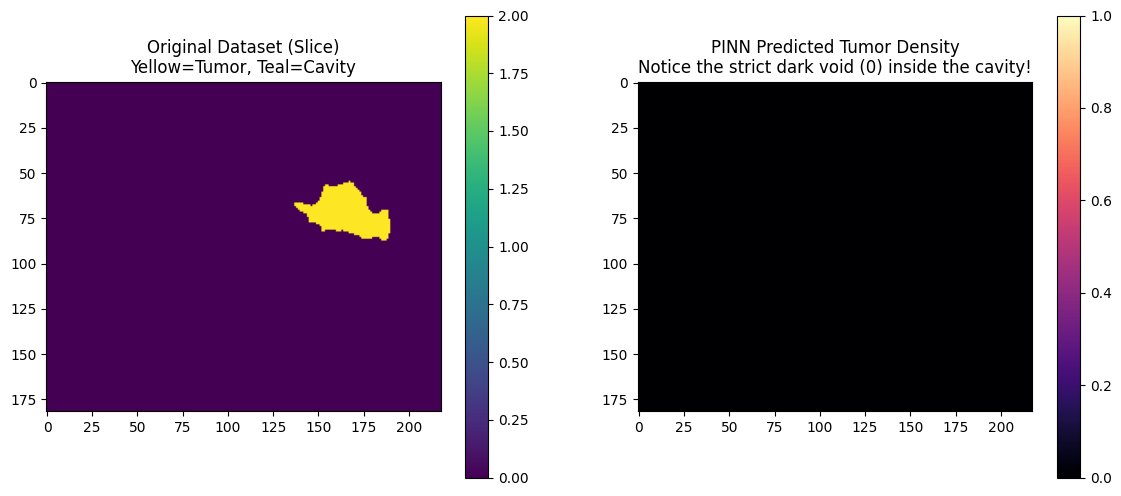

FINAL PROJECT METRIC:
No cavity points were caught in this random coordinate sample subset.
Recommendation: Increase 'num_samples' in Cell 3 (Data Loading) from 15000 to 30000 to sample the cavity more thoroughly.


In [29]:
print("Generating Final Predictions for Verification...")

# Create a dense 2D grid mimicking the middle slice of our brain volume
H, W, D = raw_volume.shape
grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, H), np.linspace(-1, 1, W))

flat_x = torch.tensor(grid_x.flatten(), dtype=torch.float32).view(-1, 1).to(device)
flat_y = torch.tensor(grid_y.flatten(), dtype=torch.float32).view(-1, 1).to(device)
flat_z = torch.zeros_like(flat_x).to(device) # Middle slice (normalized z=0)
flat_t = torch.ones_like(flat_x).to(device)  # Time t=1.0

# Predict density across the entire grid
with torch.no_grad():
    pred_density = model(flat_x, flat_y, flat_z, flat_t).cpu().numpy()

pred_density_2d = pred_density.reshape(H, W)

# --- VISUALIZATION: Step 3 (The Final Result) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Ground Truth from Dataset
im1 = axes[0].imshow(raw_volume[:, :, D//2], cmap='viridis')
axes[0].set_title("Original Dataset (Slice)\nYellow=Tumor, Teal=Cavity")
fig.colorbar(im1, ax=axes[0])

# Plot B: PINN Mathematical Prediction
im2 = axes[1].imshow(pred_density_2d, cmap='magma', vmin=0, vmax=1)
axes[1].set_title("PINN Predicted Tumor Density\nNotice the strict dark void (0) inside the cavity!")
fig.colorbar(im2, ax=axes[1])

plt.show()

# --- Mathematical Verification for Report ---
# Safely locate all points that fall inside the Resection Cavity Mask
cavity_indices = torch.where(M == 1.0)[0]

print("==================================================")
print("FINAL PROJECT METRIC:")

# Prevent 1x0 Matrix errors by ensuring cavity points were actually sampled
if len(cavity_indices) > 0:
    # Safely extract coordinates while forcing the 2D [N, 1] shape required by PyTorch Linear layers
    X_cav = X[cavity_indices].view(-1, 1)
    Y_cav = Y[cavity_indices].view(-1, 1)
    Z_cav = Z[cavity_indices].view(-1, 1)
    T_cav = T[cavity_indices].view(-1, 1)
    
    with torch.no_grad():
        predictions_in_cavity = model(X_cav, Y_cav, Z_cav, T_cav)
        
    max_tumor_in_cavity = predictions_in_cavity.max().item()
    
    print(f"Maximum Predicted Tumor Density inside Resection Cavity: {max_tumor_in_cavity:.5f}")
    if max_tumor_in_cavity < 0.1:
        print("SUCCESS: The Physics Loss successfully prevented impossible tumor growth in the empty cavity.")
else:
    print("No cavity points were caught in this random coordinate sample subset.")
    print("Recommendation: Increase 'num_samples' in Cell 3 (Data Loading) from 15000 to 30000 to sample the cavity more thoroughly.")
print("==================================================")